In [9]:
import os

import json
import numpy as np
import matplotlib.pyplot as plt

import cv2
from PIL import Image, ImageEnhance

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from keras.optimizers import Adam
from keras import regularizers
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

#warnings.filterwarnings('ignore')
%matplotlib inline

# Data loading and  augmentation

In [ ]:
def load_data_original (directorio, etiqueta):
    archivos= os.listdir(directorio)
    imagenes = []
    etiquetas = []

    for img in archivos:
        ruta_imagen = os.path.join(directorio, img)
        imagen = cv2.imread(ruta_imagen)
        imagen = cv2.resize(imagen, (250, 325))
        imagenes.append(imagen)
        etiquetas.append(etiqueta)
    return imagenes, etiquetas

def aument_data_and_image_enhace(directorio, etiqueta):
    archivos= os.listdir(directorio)
    imagenes = []
    etiquetas = []
    datagen = ImageDataGenerator(horizontal_flip=True,
                                 vertical_flip=True,
                                 zoom_range=0.2,
                                 rotation_range=90)

    for img in archivos:
        ruta_imagen = os.path.join(directorio, img)
        imagen = cv2.imread(ruta_imagen)
        imagen = cv2.resize(imagen, (250, 325))

        eq_b, eq_g, eq_r = cv2.split(imagen)
        eq_b = cv2.equalizeHist(eq_b)
        eq_g = cv2.equalizeHist(eq_g)
        eq_r = cv2.equalizeHist(eq_r)
        imagen_equalizada = cv2.merge((eq_b, eq_g, eq_r))

        brillo=0.2
        contraste=4.0
        bordes=10.0 #10
        imagen_PIL = Image.fromarray(cv2.cvtColor(imagen_equalizada, cv2.COLOR_BGR2RGB))

        enhancer = ImageEnhance.Brightness(imagen_PIL)
        imagen = enhancer.enhance(brillo)

        enhancer = ImageEnhance.Contrast(imagen)
        imagen = enhancer.enhance(contraste)

        enhancer = ImageEnhance.Sharpness(imagen)
        imagen = enhancer.enhance(bordes)

        imagenes.append(np.array(imagen.convert('L')) / 255.0)
        etiquetas.append(etiqueta)

        # data augmentation
        imagen = np.expand_dims(imagen.convert('L'), axis=0)
        imagen = np.expand_dims(imagen, axis=-1)
        iterador = datagen.flow(imagen)

        #aumentx2
        for i in range(2):
            imagen_aumentada = iterador.next()

            imagen_aumentada = np.squeeze(imagen_aumentada, axis=0)
            imagen_aumentada = np.squeeze(imagen_aumentada, axis=-1)

            imagen = np.array(imagen_aumentada) / 255.0

            imagenes.append(imagen)
            etiquetas.append(etiqueta)
    return imagenes, etiquetas

In [ ]:
#paths
original_bien = "data_final/train/0"
original_mal = "data_final/train/1"

#data loading
imagen_original_bien, tag_bien  = load_data_original(original_bien, 0)
imagenes_bien, etiquetas_bien,  = aument_data_and_image_enhace(original_bien, 0)

imagen_original_mal, tag_mal = load_data_original(original_mal, 1)
imagenes_mal, etiquetas_mal,  = aument_data_and_image_enhace(original_mal, 1)

imagenes = np.concatenate((imagenes_bien, imagenes_mal), axis=0)
etiquetas = np.concatenate((etiquetas_bien, etiquetas_mal), axis=0)

In [4]:
len(imagenes), len(etiquetas)

(25674, 25674)

# Data visualization

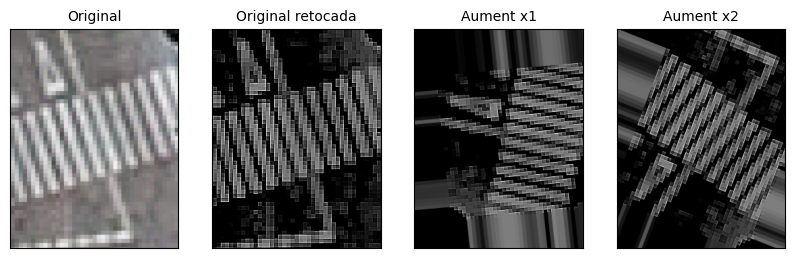

In [ ]:
fig = plt.figure(figsize=(10, 5))

#original
ax = fig.add_subplot(1, 4, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.imshow(imagen_original_bien[300])
ax.set_title("Original", fontsize=10)

#original 2
ax = fig.add_subplot(1, 4, 2)
ax.set_xticks([])
ax.set_yticks([])
ax.imshow(imagenes_bien[900],  cmap='gray')
ax.set_title("Original retocada", fontsize=10)

#aument 1
ax = fig.add_subplot(1, 4, 3)
ax.set_xticks([])
ax.set_yticks([])
ax.imshow(imagenes_bien[901],  cmap='gray')
ax.set_title("Aument x1", fontsize=10)

#aument 2
ax = fig.add_subplot(1, 4, 4)
ax.set_xticks([])
ax.set_yticks([])
ax.imshow(imagenes_bien[902],  cmap='gray')
ax.set_title("Aument x2", fontsize=10)
plt.show()

# Train-Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(imagenes, etiquetas, test_size=0.2, random_state=123)
X_train.shape, X_test.shape
del imagenes
del etiquetas

# Model architecture

In [ ]:
modelo = Sequential()

modelo.add(Conv2D(filters=32, kernel_size=(5, 5), input_shape=(325, 250, 1), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
modelo.add(MaxPooling2D((2, 2)))

modelo.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
modelo.add(MaxPooling2D((2, 2)))

modelo.add(Conv2D(filters=128, kernel_size=(5, 5), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
modelo.add(MaxPooling2D((2, 2)))

modelo.add(Flatten())

modelo.add(Dense(units=1024, activation='relu', kernel_regularizer=regularizers.l2(0.01)))

modelo.add(Dense(units=2, activation='softmax'))
modelo.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 321, 246, 32)      832       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 160, 123, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 156, 119, 64)      51264     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 78, 59, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 74, 55, 128)       204928    
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 37, 27, 128)      0

# Train

In [ ]:
epochs=30
batch_size=50
learn_rate=0.0001
my_opt = Adam(learning_rate=learn_rate)

#train loop
modelo.compile(optimizer=my_opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
resume = modelo.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

Epoch 1/30
329/329 [==============================] - 786s 2s/step - loss: 2.8544 - accuracy: 0.6840 - val_loss: 0.9792 - val_accuracy: 0.7481
Epoch 2/30
329/329 [==============================] - 843s 3s/step - loss: 0.8887 - accuracy: 0.7573 - val_loss: 0.9671 - val_accuracy: 0.6796
Epoch 3/30
329/329 [==============================] - 837s 3s/step - loss: 0.7944 - accuracy: 0.7685 - val_loss: 0.7436 - val_accuracy: 0.7960
Epoch 4/30
329/329 [==============================] - 840s 3s/step - loss: 0.7286 - accuracy: 0.7892 - val_loss: 0.7073 - val_accuracy: 0.7936
Epoch 5/30
329/329 [==============================] - 840s 3s/step - loss: 0.6825 - accuracy: 0.8021 - val_loss: 0.6460 - val_accuracy: 0.8252
Epoch 6/30
329/329 [==============================] - 842s 3s/step - loss: 0.6597 - accuracy: 0.8046 - val_loss: 0.6441 - val_accuracy: 0.8118
Epoch 7/30
329/329 [==============================] - 843s 3s/step - loss: 0.6266 - accuracy: 0.8143 - val_loss: 0.5997 - val_accuracy: 0.8269

In [ ]:
if not os.path.exists("models"):
    os.mkdir("models")

with open("models/training_history.json", "w") as f:
    json.dump(resume.history, f)

modelo.save("models/CNN0.h5")

# Evaluation and predictions

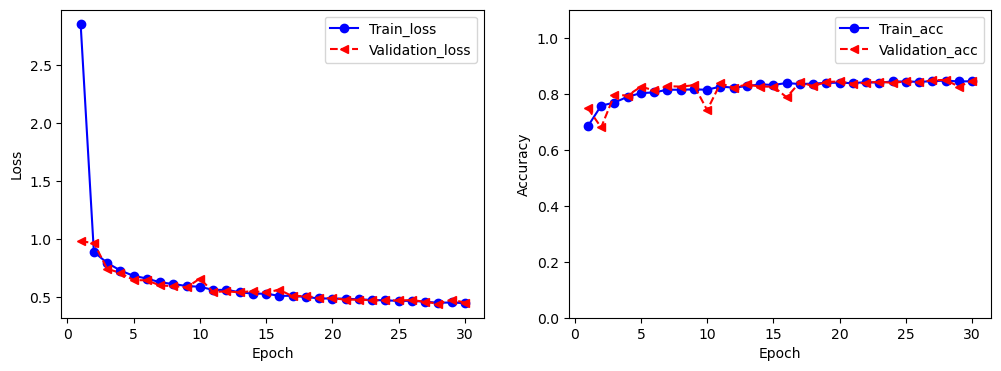

In [10]:
hist = resume.history
x_arr = np.arange(len(hist["loss"]))+1
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,2,1)
ax.plot(x_arr, hist["loss"], "-o", label="Train_loss", color="b")
ax.plot(x_arr, hist["val_loss"], "--<", label="Validation_loss", color="r")
ax.set_xlabel('Epoch', size=10)
ax.set_ylabel('Loss', size=10)
#ax.set_ylim(0,4)
ax.legend(fontsize=10)

ax = fig.add_subplot(1,2,2)
ax.plot(x_arr, hist["accuracy"], "-o", label="Train_acc", color="b")
ax.plot(x_arr, hist["val_accuracy"], "--<", label="Validation_acc", color="r")
ax.set_xlabel('Epoch', size=10)
ax.set_ylabel('Accuracy', size=10)
ax.set_ylim(0,1.1)
ax.legend(fontsize=10)

### Test

In [22]:
ACC = modelo.evaluate(X_test, y_test, verbose=0)[1]
print("Test Accuracy: {}".format(round(ACC,3)))

Test Accuracy: 0.849


### Predictions

In [37]:
def load_data(directorio, etiqueta):
    archivos= os.listdir(directorio)
    imagenes = []
    etiquetas = []

    for img in archivos:
        ruta_imagen = os.path.join(directorio, img)
        imagen = cv2.imread(ruta_imagen)
        imagen = cv2.resize(imagen, (250, 325))

        eq_b, eq_g, eq_r = cv2.split(imagen)
        eq_b = cv2.equalizeHist(eq_b)
        eq_g = cv2.equalizeHist(eq_g)
        eq_r = cv2.equalizeHist(eq_r)
        imagen_equalizada = cv2.merge((eq_b, eq_g, eq_r))

        brillo=0.2
        contraste=4.0
        bordes=10.0
        imagen_PIL = Image.fromarray(cv2.cvtColor(imagen_equalizada, cv2.COLOR_BGR2RGB))

        #Brillo
        enhancer = ImageEnhance.Brightness(imagen_PIL)
        imagen = enhancer.enhance(brillo)

        #Contraste
        enhancer = ImageEnhance.Contrast(imagen)
        imagen = enhancer.enhance(contraste)

        #Bordes
        enhancer = ImageEnhance.Sharpness(imagen)
        imagen = enhancer.enhance(bordes)

        # guardar imagen original mejorada
        imagen = imagen.convert('L')
        imagenes.append(np.array(imagen) / 255.0)
        etiquetas.append(etiqueta)

    return imagenes, etiquetas

In [38]:
bien = "data_final/test/0"
mal = "data_final/test/1"

imgs_0, labels_0 = load_data(bien, 0)
imgs_1, labels_1 = load_data(mal, 1)

imgs = np.array(imgs_0 + imgs_1)
labels = np.array(labels_0 + labels_1)

In [39]:
modelo= keras.models.load_model('models/CNN0.h5')

In [40]:
preds = modelo.predict(imgs)
pd = np.argmax(preds, axis=1)

1/1 [==============================] - 0s 251ms/step


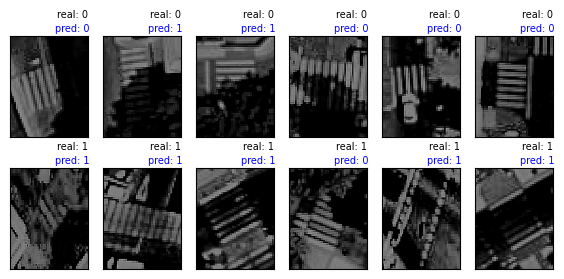

In [41]:
fig = plt.figure(figsize=(7,10))
i=0
for img, label in zip(imgs, labels):
    ax = fig.add_subplot(6,6,i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img, cmap="gray")
    ax.text(200, -25,'pred: {}'.format(pd[i]), size=7, color="blue", ha='center',va='center')
    ax.text(200, -70,'real: {}'.format(label), size=7, color="black", ha='center',va='center')
    i+=1
plt.show()